## makeover monday 2026-04-06

### global oil production

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://query.data.world/s/fk3hww4mt5aswsiwi55wg7h4wkzj2a?dws=00000')
df.tail(2)

,Entity,Code,Year,Oil
873,United States,USA,2023,9647.618
874,United States,USA,2024,9977.384


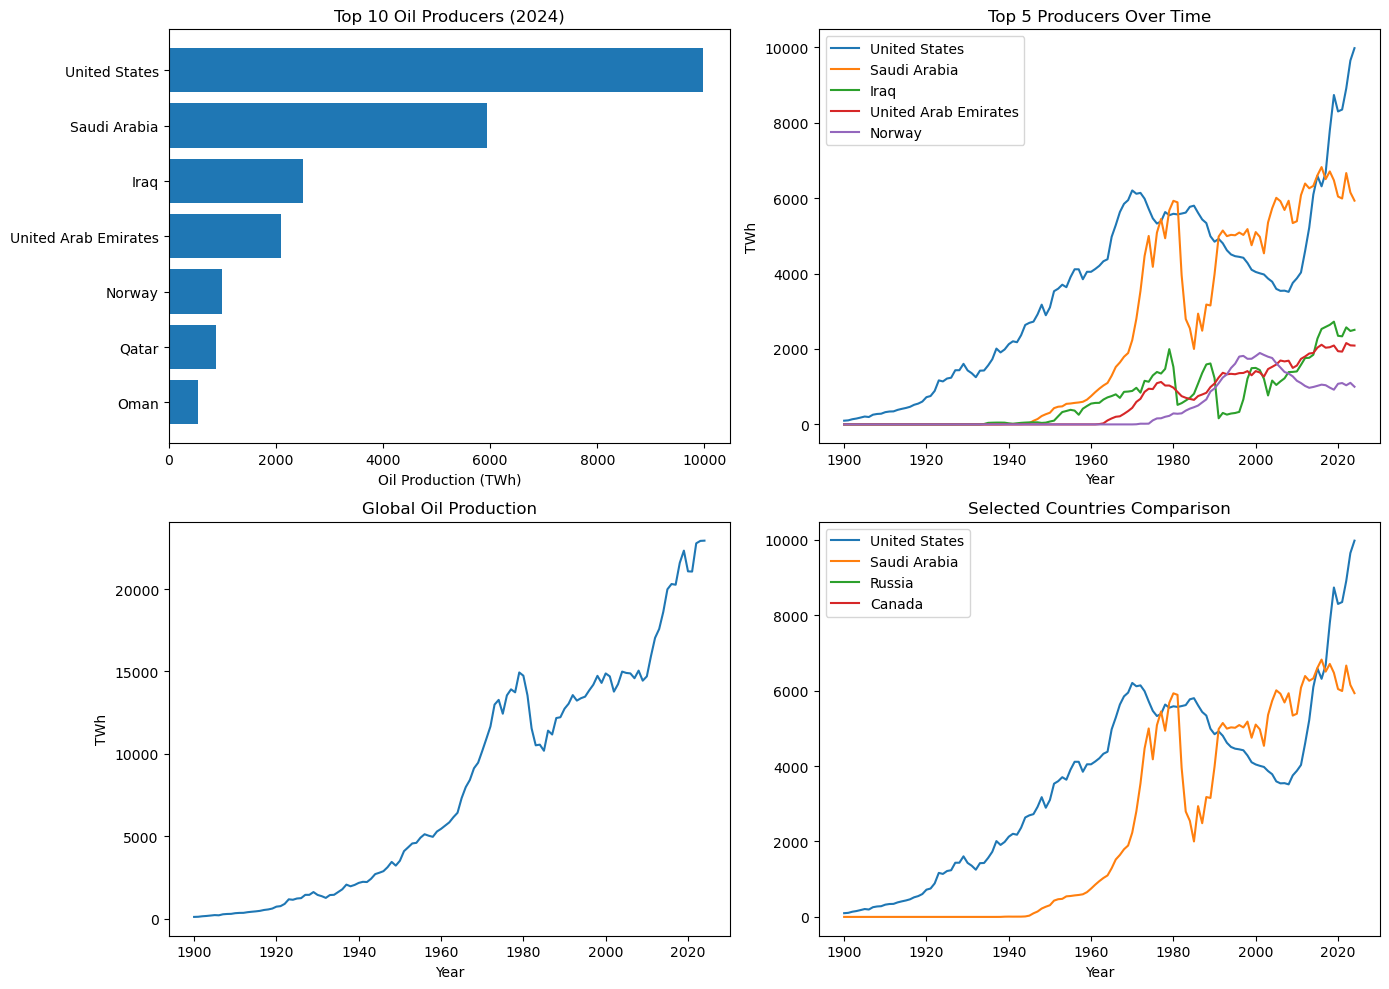

In [5]:
# Basic cleanup
df = df.rename(columns={"Oil production - TWh": "Oil"})
df = df.dropna(subset=["Oil"])

# -----------------------------
# Prepare data
# -----------------------------

# Latest year
latest_year = df["Year"].max()
df_latest = df[df["Year"] == latest_year]

# Top 10 countries
top10 = df_latest.sort_values("Oil", ascending=False).head(10)

# Top 5 countries over time
top5_countries = top10["Entity"].head(5).tolist()
df_top5 = df[df["Entity"].isin(top5_countries)]

# World data - Compute global total manually
df_world = df.groupby("Year", as_index=False)["Oil"].sum()

# Selected countries
selected = ["United States", "Saudi Arabia", "Russia", "Canada"]
df_selected = df[df["Entity"].isin(selected)]

# -----------------------------
# Plot 2x2 grid
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- (1) Top 10 countries (bar)
axes[0, 0].barh(top10["Entity"], top10["Oil"])
axes[0, 0].set_title(f"Top 10 Oil Producers ({latest_year})")
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel("Oil Production (TWh)")

# ---- (2) Top 5 time series
for country in top5_countries:
    data = df_top5[df_top5["Entity"] == country]
    axes[0, 1].plot(data["Year"], data["Oil"], label=country)

axes[0, 1].set_title("Top 5 Producers Over Time")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("TWh")
axes[0, 1].legend()

# ---- (3) World total
axes[1, 0].plot(df_world["Year"], df_world["Oil"])
axes[1, 0].set_title("Global Oil Production")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("TWh")

# ---- (4) Selected countries comparison
for country in selected:
    data = df_selected[df_selected["Entity"] == country]
    axes[1, 1].plot(data["Year"], data["Oil"], label=country)

axes[1, 1].set_title("Selected Countries Comparison")
axes[1, 1].set_xlabel("Year")
axes[1, 1].legend()

plt.tight_layout()
plt.show()